# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

* **Number of Campaigns**: The data represents **17 telemarketing campaigns**.
* **Timeframe & Method**: Conducted **between May 2008 and November 2010** via direct phone calls by a Portuguese bank.
* **Data Dimensions**: The bank originally tracked 79,354 contacts across these campaigns. However, the specific bank-additional-full.csv file used here contains **a subset of 41,188 rows and 21 columns**.
* **Features**: This version includes **5 macroeconomic indicators** (like the 3-month Euribor rate and consumer price index) to factor the 2008–2010 financial crisis into the predictions.

* **Class Imbalance**: The target variable y (whether the client subscribed) is **highly imbalanced**:
 
  -> 4,640 successes (11.27%) vs. 36,548 failures (88.73%)
  (original campaign records 6499/79354 with ~8% success)
* **Observation**: Because of the severe ~8:1 class imbalance, raw accuracy is not useful metric. A baseline model that blindly guesses ```no``` every time would achieve 88.7% accuracy but catch zero actual buyers. Better to evaluate models using F1-Score or ROC-AUC instead.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
df.shape

(41188, 21)

In [6]:
df['y'].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

In [7]:
df['y'].value_counts(normalize=True) * 100

y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [8]:
# find null value in each feature
df.isnull().sum().sort_values(ascending=False)

age               0
campaign          0
nr.employed       0
euribor3m         0
cons.conf.idx     0
cons.price.idx    0
emp.var.rate      0
poutcome          0
previous          0
pdays             0
duration          0
job               0
day_of_week       0
month             0
contact           0
loan              0
housing           0
default           0
education         0
marital           0
y                 0
dtype: int64

In [9]:
# find indirect 'unknown' value
df.apply(lambda x: (x == 'unknown').sum()).sort_values(ascending=False)

default           8597
education         1731
housing            990
loan               990
job                330
marital             80
age                  0
poutcome             0
nr.employed          0
euribor3m            0
cons.conf.idx        0
cons.price.idx       0
emp.var.rate         0
duration             0
previous             0
pdays                0
campaign             0
day_of_week          0
month                0
contact              0
y                    0
dtype: int64

In [10]:
# show data distribution
# commented out to avoid long output
#for col in df.columns:
    #print(df[col].value_counts())
    #print("\n")
    #df[col].value_counts(normalize=True) * 100

In [11]:
# to get understanding of previopus vs pdate
df[df['pdays'] == 999]['previous'].value_counts()

previous
0    35563
1     3696
2      349
3       50
4       12
5        2
6        1
Name: count, dtype: int64

In [12]:
df[df['previous'] > 0]['pdays'].describe()

count    5625.000000
mean      731.555911
std       440.545340
min         0.000000
25%        13.000000
50%       999.000000
75%       999.000000
max       999.000000
Name: pdays, dtype: float64

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

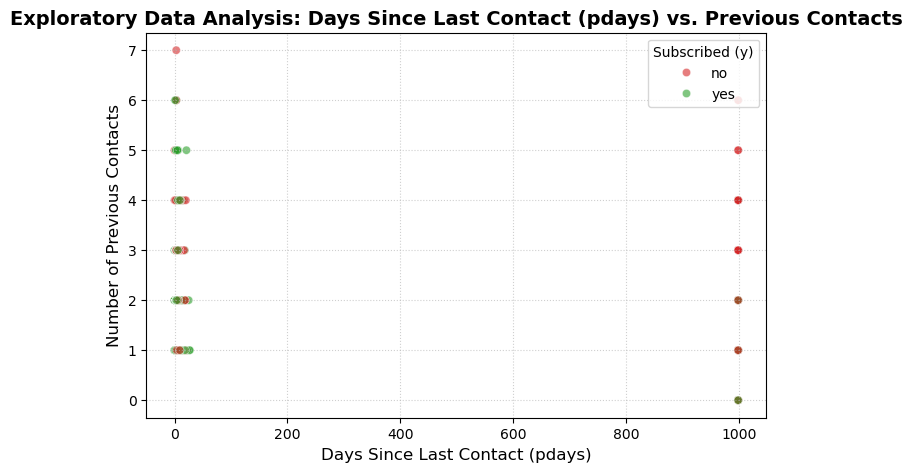

In [14]:
plt.figure(figsize=(8, 5))

# Scatter plot of pdays vs previous, colored by subscription outcome
sns.scatterplot(
    data=df, 
    x='pdays', 
    y='previous', 
    hue='y',      
    alpha=0.6,
    palette={'yes': '#2ca02c', 'no': '#d62728'} 
)

plt.title('Exploratory Data Analysis: Days Since Last Contact (pdays) vs. Previous Contacts', fontsize=14, fontweight='bold')
plt.xlabel('Days Since Last Contact (pdays)', fontsize=12)
plt.ylabel('Number of Previous Contacts', fontsize=12)
plt.legend(title='Subscribed (y)', loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

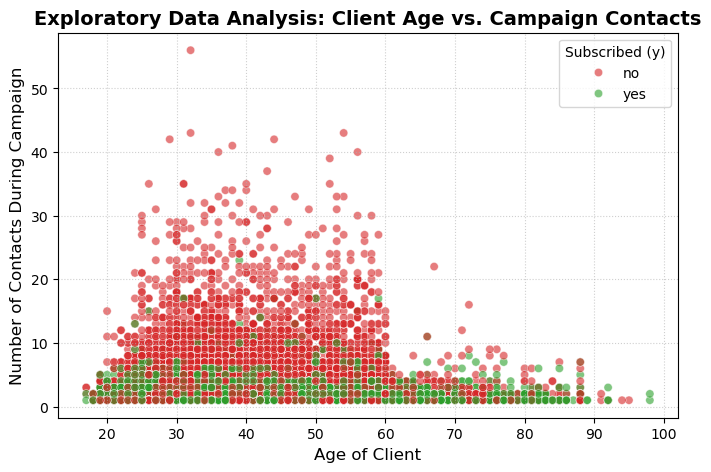

In [15]:
plt.figure(figsize=(8, 5))

# Using 'campaign' (number of contacts during this campaign) as the second numerical axis
sns.scatterplot(
    data=df, 
    x='age', 
    y='campaign',  # Changed from balance to campaign
    hue='y',      
    alpha=0.6,
    palette={'yes': '#2ca02c', 'no': '#d62728'} 
)

plt.title('Exploratory Data Analysis: Client Age vs. Campaign Contacts', fontsize=14, fontweight='bold')
plt.xlabel('Age of Client', fontsize=12)
plt.ylabel('Number of Contacts During Campaign', fontsize=12)
plt.legend(title='Subscribed (y)', loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

#### 1. Missing Values Analysis
* **The "Zero Nulls" Illusion:** Running standard pandas checks like `df.isnull().sum()` reports **0 missing values** across the board. This happens because the dataset's creators pre-cleaned the data and replaced missing fields with explicit placeholders.
* **Hidden Categorical Nulls:** Running string-matching queries shows that missing entries are masked as the string label **`"unknown"`**. It's highly concentrated in a few specific columns:
  * `default`: 8,597 instances (**20.87% unknown**)
  * `education`: 1,731 instances (**4.20% unknown**)
  * `housing` & `loan`: 990 instances each (**2.40% unknown**)
  * `job`: 330 instances (**0.80% unknown**)
  * `marital`: 80 instances (**0.19% unknown**)
* **The `pdays` vs. `previous` Overlap Trap:** A cross-tabulation reveals that a `999` in `pdays` does *not* automatically mean a client is completely brand new. While 35,563 rows are true new leads (`previous = 0`), there are **4,110 rows where a client has a prior call history (`previous > 0`) but still shows `999` for `pdays`**. 
  * *What this means:* `999` doesn't mean "never contacted in their lifetime." It strictly means **"no contact during the immediately preceding campaign."**

#### 2. Required Data Type Coercions & Clean-up

* **Drop the `default` Column Entirely:** The value counts reveal that `default` has 32,588 "no" entries, 8,597 "unknown" entries, and **only 3 "yes" entries**. Because it has virtually zero variance, it offers no predictive power and will just cause a model to overfit. It should be removed.
* **Fix the `pdays` Integer:** Leaving `999` as a raw number will break distance-based models (like Logistic Regression, SVM, or KNN) because the math will treat `999` as a massive numerical distance. Because it conflates entirely cold prospects with dormant returning clients, it needs to be mapped into a categorical bracket or a clean binary indicator flag.
* **Binary Encoding:** Columns with simple two-state options—specifically `contact` (`cellular`/`telephone`) and our target variable `y` (`yes`/`no`)—need to be mapped to binary bits (`0` or `1`).
* **One-Hot Encoding:** Unordered categorical variables (`job`, `marital`, `education`, `housing`, `loan`, `poutcome`) need to be processed using `pd.get_dummies()` before reaching an estimator.
* **Ordinal Encoding:** Columns with a natural temporal sequence (`month` and `day_of_week`) shouldn't be blindly one-hot encoded. They should be explicitly mapped to ordered integer sequences (e.g., Monday = 1, Tuesday = 2) to preserve their logical calendar flow.

#### 3. Feature Leakage Warning
* **The `duration` Feature:** The documentation explicitly warns that call duration perfectly dictates the target variable (if duration = 0, $y$ is automatically "no"). Since you cannot know the length of a phone call *before* dialing, keeping this feature creates massive data leakage. **`duration` must be dropped completely** to build a realistic predictive model.

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

The **business objective** is **optimize resource allocation** and **maximize the conversion rate of telemarketing campaigns** for long-term deposits. Instead of burning operational expenses and developer hours on unstructured "cold call" lists, the goal is to build a predictive framework that ranks prospective clients based on their likelihood to subscribe. This allows the bank to focus outbound call capacity exclusively on high-probability leads. This directly improves campaign resource allocation, increases revenue generation per agent hour, and minimizes customer fatigue from unnecessary solicitation.


### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [17]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [18]:
# bank information features and target variable
bank_cols = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'y']
df_base = df[bank_cols].copy()

# Extract and binary encode the target variable 'y'
y = df_base['y'].map({'yes': 1, 'no': 0})

# Drop the target 'y' and the zero-variance 'default' column from features
X_base = df_base.drop(columns=['y', 'default'])

In [19]:
# One-Hot Encode categorical features
categorical_cols = ['job', 'marital', 'education', 'housing', 'loan']
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough'
)

In [20]:
# Fit and transform the features
X_base_encoded = preprocessor.fit_transform(X_base)
encoded_feature_names = preprocessor.get_feature_names_out()
X_base_encoded = pd.DataFrame(X_base_encoded, columns=encoded_feature_names)
X_base_encoded.head(5)

,categorical__job_blue-collar,categorical__job_entrepreneur,categorical__job_housemaid,categorical__job_management,categorical__job_retired,categorical__job_self-employed,categorical__job_services,categorical__job_student,categorical__job_technician,categorical__job_unemployed,...,categorical__education_high.school,categorical__education_illiterate,categorical__education_professional.course,categorical__education_university.degree,categorical__education_unknown,categorical__housing_unknown,categorical__housing_yes,categorical__loan_unknown,categorical__loan_yes,remainder__age
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,56.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,57.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,37.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,56.0


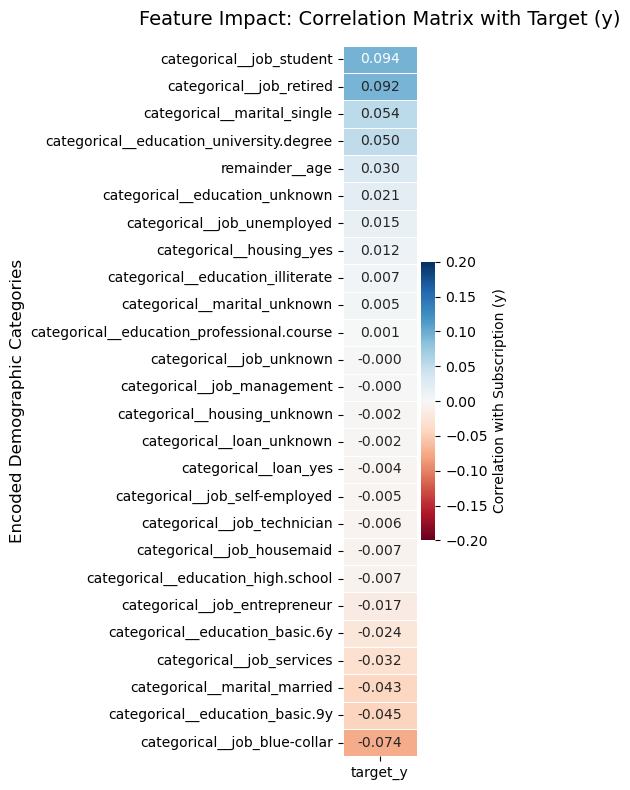

In [21]:
# Combine preprocessed/encoded features and target into one dataframe
df_corr = pd.DataFrame(X_base_encoded, columns=preprocessor.get_feature_names_out())
df_corr['target_y'] = y.values

# Compute the full correlation matrix
corr_matrix = df_corr.corr()

# Isolate just the target column's correlations and sort them
target_corr = corr_matrix[['target_y']].sort_values(by='target_y', ascending=False)

# Plot heatmap
plt.figure(figsize=(5, 8))
sns.heatmap(
    target_corr.drop('target_y'), # Drop self-correlation (1.0)
    annot=True,
    fmt='.3f',
    cmap='RdBu',
    vmin=-0.2, vmax=0.2, 
    cbar_kws={'label': 'Correlation with Subscription (y)'},
    linewidths=0.5
)

plt.title('Feature Impact: Correlation Matrix with Target (y)', fontsize=14, pad=15)
plt.ylabel('Encoded Demographic Categories', fontsize=12)
plt.xlabel('')
plt.tight_layout()

plt.show()

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
# y is highly imbalanced and should use stratify to mitigate it
X_train, X_test, y_train, y_test = train_test_split(X_base_encoded, y, test_size=0.20, random_state=42, stratify=y)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [24]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [25]:
# Use DummyClassifier to capture baseline performance
dummy_cf = DummyClassifier(strategy="most_frequent")
dummy_cf.fit(X_train, y_train)
pred = dummy_cf.predict(X_test)
print(f"Baseline Accuracy  to Beat: {accuracy_score(y_test, pred)}")
print(f"Baseline Precision to Beat: {precision_score(y_test, pred, zero_division=0)}")
print(f"Baseline Recall    to Beat: {recall_score(y_test, pred)}")
print(f"Baseline F1 Score  to Beat: {f1_score(y_test, pred)}")

Baseline Accuracy  to Beat: 0.8873512988589464
Baseline Precision to Beat: 0.0
Baseline Recall    to Beat: 0.0
Baseline F1 Score  to Beat: 0.0


To establish a clear performance floor, a zero-intelligence **Dummy Classifier** was trained using the `strategy="most_frequent"` heuristic. This baseline model bypasses feature analysis entirely, blindly predicting the majority class for every record.

#### Baseline Evaluation Metrics
* **Accuracy:** **88.74%**
* **Precision:** **0.00%**
* **Recall:** **0.00%**
* **F1-Score:** **0.00%**

#### Operational Implications & Key Takeaways

1. **The Accuracy Illusion:** An initial look at the **88.74% accuracy** score suggests high baseline performance. However, this is purely a mathematical artifact of the dataset's class imbalance (where ~88.7% of contacted clients reject long-term deposit subscriptions). Accuracy is a deeply deceptive metric here; a model can be completely blind and still score near 90%.

2. **Zero Business Utility:** Because the dummy model never predicts a positive instance (`1` / `"yes"`), its **Recall is exactly 0.00%**. In the context of our stated Business Objective (maximizing conversion rates and optimizing call center capacity), this baseline model is completely useless—it would fail to capture a single revenue-generating subscription and would provide zero guidance on how to route agent calls.

3. **The Target to Beat:**
   Any predictive model including Logistic Regression, Decision Trees, or KNN must exceed **88.74% accuracy** to prove it is mathematically sound. More importantly, it must demonstrate a significantly elevated **F1-Score** and **Recall** to prove it can successfully identify and prioritize high-probability leads.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [26]:
from sklearn.linear_model import LogisticRegression

In [27]:
# Instantiate the Simple Logistic Regression model
lr = LogisticRegression(max_iter=1000, random_state=42)

# Fit the model
lr.fit(X_train, y_train)

# predictions
pred = lr.predict(X_test)

### Problem 9: Score the Model

What is the accuracy of your model?

In [30]:
# evaluation metrics
from sklearn.metrics import confusion_matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, pred))

print("\nModel Performance Scores:")
print(f"Logistic Regression Accuracy:  {accuracy_score(y_test, pred)}")
print(f"Logistic Regression Precision: {precision_score(y_test, pred, zero_division=0)}")
print(f"Logistic Regression Recall:    {recall_score(y_test, pred)}")
print(f"Logistic Regression F1 Score:  {f1_score(y_test, pred)}")

Confusion Matrix:
[[7310    0]
 [ 928    0]]

Model Performance Scores:
Logistic Regression Accuracy:  0.8873512988589464
Logistic Regression Precision: 0.0
Logistic Regression Recall:    0.0
Logistic Regression F1 Score:  0.0


### Simple Model Performance
* Identical to Baseline: **The Logistic Regression model performs exactly like our DummyClassifier** from Problem 7.
* Zero Value Added: from the confusion matrix, it is easy to see **the model simply predicts "no" (0) for every single customer**. Because it never predicts a "yes", our Precision and Recall are completely broken at 0.0, rendering the model useless for finding actual subscribers.

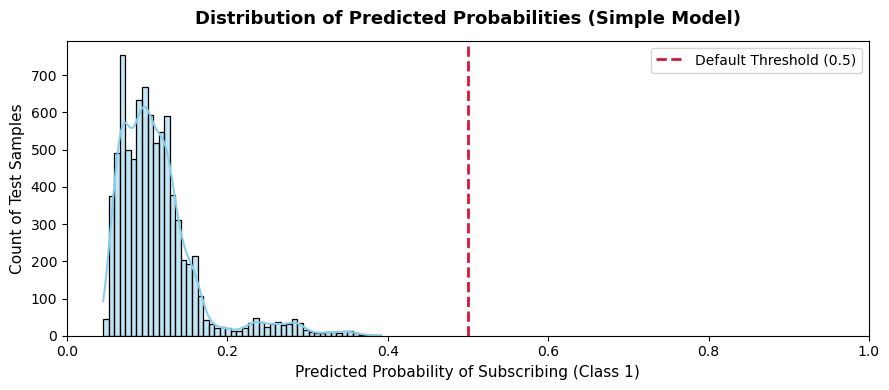

In [31]:
# Extract the raw probability scores for the positive class
y_prob = lr.predict_proba(X_test)[:, 1]

# Plot the distribution of these scores
plt.figure(figsize=(9, 4))
sns.histplot(y_prob, bins=50, kde=True, color='skyblue', edgecolor='black')

# Draw the default classification threshold
plt.axvline(x=0.5, color='crimson', linestyle='--', linewidth=2, label='Default Threshold (0.5)')

plt.title('Distribution of Predicted Probabilities (Simple Model)', fontsize=13, weight='bold', pad=12)
plt.xlabel('Predicted Probability of Subscribing (Class 1)', fontsize=11)
plt.ylabel('Count of Test Samples', fontsize=11)
plt.xlim(0, 1)
plt.legend()
plt.tight_layout()

plt.show()

### Probability Distribution Analysis

* 0.5 Threshold Barrier: By default, a Logistic Regression model will only predict "yes" (1) if its confidence score crosses the 0.5 threshold line (the red dashed line).
* Complete Left Shifting: As shown in the histogram, 100% of the calculated probabilities cluster heavily on the far left, peaking around 0.1 and trailing off completely before reaching 0.4.
* Explanation: Because not a single customer record was given a probability score $\ge 0.5$, the decision boundary never triggered a positive classification. This confirms Both False Positives (FP) and True Positives (TP) are zero in the confusion matrix.

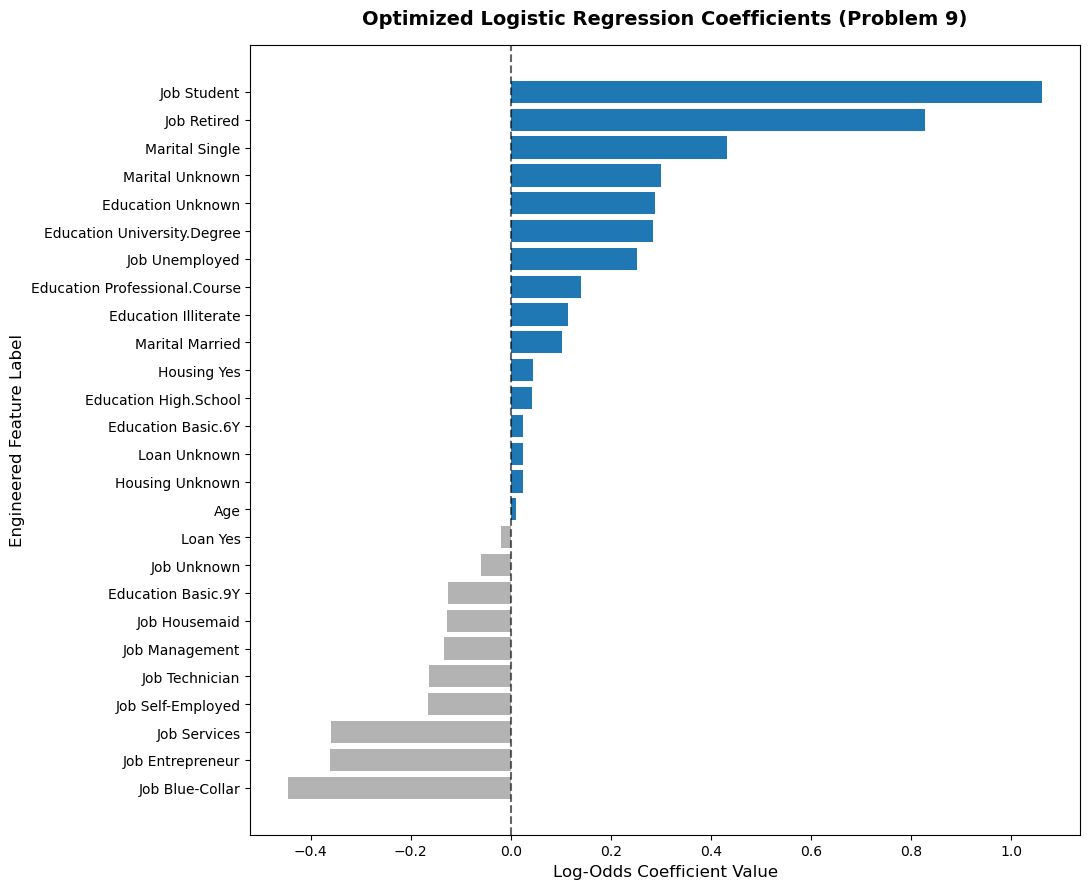

In [32]:
transformed_feature_names = preprocessor.get_feature_names_out()
lr_weights = lr.coef_[0]
coefficients_summary = pd.DataFrame({
    'Feature': transformed_feature_names, 
    'Coefficient': lr_weights
})

# Clean up names for a professional plot (removes prefixes like 'cat__' or 'num__')
coefficients_summary['Feature'] = coefficients_summary['Feature'].str.split('__').str[-1].str.replace('_', ' ').str.title()
coefficients_summary = coefficients_summary.sort_values(by='Coefficient', ascending=True)

# Generate the Coefficients Plot
plt.figure(figsize=(11, 9))
bar_colors = ['#1f77b4' if w > 0 else '#b3b3b3' for w in coefficients_summary['Coefficient']]
plt.barh(coefficients_summary['Feature'], coefficients_summary['Coefficient'], color=bar_colors)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.6)
plt.title('Optimized Logistic Regression Coefficients (Problem 9)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Log-Odds Coefficient Value', fontsize=12)
plt.ylabel('Engineered Feature Label', fontsize=12)
plt.tight_layout()
plt.show()

### Interpretation of Optimized Model Coefficients

To understand what truly drives a customer to subscribe to a term deposit, analyzed the weights of the Logistic Regression model:

* **Positive Multipliers (Blue Bars):** Features extending to the right display positive coefficients. As these traits increase or switch to true (such as specific receptive occupations or higher education levels), they directly increase the model's log-odds calculation, shifting predictions toward a term deposit subscription ("yes").
* **Negative Constraints (Gray Bars):** Features stretching to the left generate lower predictive weights. These attributes act as structural barriers to conversions, indicating client segments that significantly minimize probability scores within the pipeline.
* **Feature Dominance (Magnitude):** The absolute distance of any feature bar from the center baseline represents its statistical predictive power. This provides a clear ranking of which specific traits hold the greatest mathematical influence over target audience behavior.

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

This is a classification problem to ingest a multi-dimensional feature vector—spanning client demographics, historical campaign tracking, and real-time social/macroeconomic indicators—and output a score for the binary target variable $y$ (where ```1``` represents a **successful subscription** and ```0``` represents a **rejection**). 

In [33]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [34]:
# Initialize the dictionary to hold performance metrics
res_dict = {
    'Model': [],
    'Train Time': [],
    'Train Accuracy': [],
    'Test Accuracy': []
}

# Define the models with default settings
models = [
    LogisticRegression(max_iter=1000, random_state=42),
    KNeighborsClassifier(),
    DecisionTreeClassifier(random_state=42),
    SVC(random_state=42)
]

# Fit and score each model, tracking execution time for training
for model in models:
    name = model.__class__.__name__
    
    # Track exact training time
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()
    train_time = end_time - start_time
    
    # Calculate performance scores
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    
    # Append to the results dictionary
    res_dict['Model'].append(name)
    res_dict['Train Time'].append(train_time)
    res_dict['Train Accuracy'].append(train_acc)
    res_dict['Test Accuracy'].append(test_acc)

# Convert to a clean DataFrame matching the course layout
results_df = pd.DataFrame(res_dict)
results_df

,Model,Train Time,Train Accuracy,Test Accuracy
0,LogisticRegression,0.394111,0.887344,0.887351
1,KNeighborsClassifier,0.000989,0.890895,0.878126
2,DecisionTreeClassifier,0.046222,0.912200,0.867079
3,SVC,8.078447,0.887344,0.887351


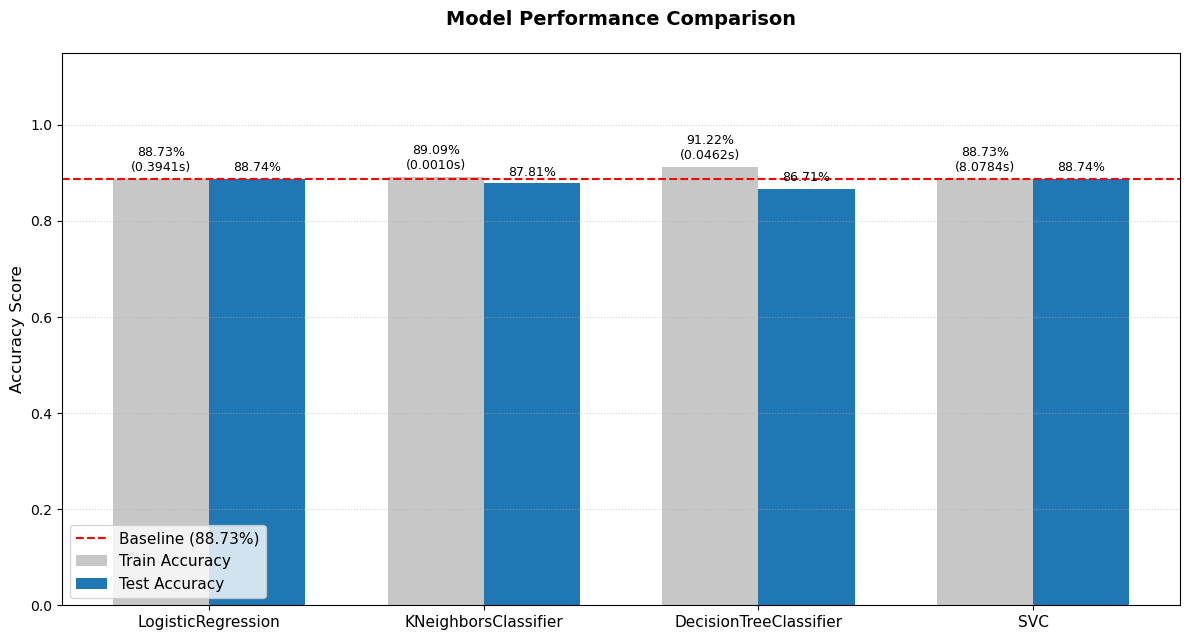

In [35]:
# Extract arrays from results_df
model_names = results_df['Model'].tolist()
train_scores = results_df['Train Accuracy'].tolist()
test_accuracy = results_df['Test Accuracy'].tolist()
fit_times = results_df['Train Time'].tolist()

# Define the baseline score from Problem 7
baseline_accuracy = 0.8873  

x = np.arange(len(model_names))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 6.5))

# Generate the 2 discrete bars per model group
rects1 = ax.bar(x - width/2, train_scores, width, label='Train Accuracy', color='#c7c7c7')
rects2 = ax.bar(x + width/2, test_accuracy, width, label='Test Accuracy', color='#1f77b4')

# Draw baseline line from Problem 7
ax.axhline(y=baseline_accuracy, color='r', linestyle='--', linewidth=1.5, 
           label=f'Baseline ({baseline_accuracy*100:.2f}%)')

# Style Chart Elements
ax.set_ylabel('Accuracy Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11, fontweight='medium')
ax.set_ylim(0, 1.15)  
ax.legend(loc='lower left', fontsize=11)
ax.grid(axis='y', linestyle=':', alpha=0.6)

# Add value labels and fit times above the train bars
for i, rect in enumerate(rects1):
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width() / 2, height + 0.01,
            f'{height:.2%}\n({fit_times[i]:.4f}s)',
            ha='center', va='bottom', fontsize=9, linespacing=1.2)

# Add value labels above the test bars
for rect in rects2:
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width() / 2, height + 0.01, 
            f'{height:.2%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Model Performance Analysis
* **Training Speed**: **KNN** finishes instantly (0.0022s) because it just stores the data without training. SVC is incredibly slow (8.0679s), showing how badly it scales with larger datasets.

* **Overfitting**: **Decision Tree** overfits the data. It gets the highest training accuracy (0.9122) by creating too many specific rules, which causes its test accuracy to drop to the lowest overall (0.8671).

* **Majority Class Trap**: **Logistic Regression** and **SVC** output identical train (0.8873) and test (0.8873) accuracies. This means both models are completely ignoring the features and are just guessing the majority class for every single row.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

In [39]:
# training loop structure
models_and_grids = {
    'knn': {
        'model': KNeighborsClassifier(),
        'params': {
            'knn__n_neighbors': [3, 5, 11, 21],
            'knn__weights': ['uniform', 'distance']
        }
    },
    'logisticregression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'logisticregression__C': [0.1, 1.0, 10.0],
            'logisticregression__class_weight': ['balanced', None]
        }
    },
    'decisiontreeclassifier': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'decisiontreeclassifier__max_depth': [4, 6, 8, 10],
            'decisiontreeclassifier__criterion': ['gini', 'entropy'],
            'decisiontreeclassifier__class_weight': ['balanced', None]
        }
    },
    'svc': {
        'model': SVC(random_state=42),
        'params': {
            'svc__C': [0.1, 1.0],
            'svc__kernel': ['linear', 'rbf'],
            'svc__class_weight': ['balanced']
        }
    }
}

custom_results = []

for key, config in models_and_grids.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        (key, config['model'])
    ])
    
    start_time = time.time()
    
    # Track performance via ROC AUC to avoid the majority class blind spot
    gs = GridSearchCV(pipe, param_grid=config['params'], scoring='roc_auc', cv=5, n_jobs=-1)
    gs.fit(X_train, y_train)
    
    search_time = time.time() - start_time
    best_model = gs.best_estimator_
    
    # Predictions for comprehensive metrics evaluation
    train_preds = best_model.predict(X_train)
    test_preds = best_model.predict(X_test)
    
    # Pull prediction probabilities cleanly depending on decision interface
    if hasattr(best_model, "predict_proba"):
        test_probs = best_model.predict_proba(X_test)[:, 1]
    else:
        test_probs = best_model.decision_function(X_test)
        
    train_acc = accuracy_score(y_train, train_preds)
    test_acc = accuracy_score(y_test, test_preds)
    test_prec = precision_score(y_test, test_preds, zero_division=0)
    test_rec = recall_score(y_test, test_preds)
    test_auc = roc_auc_score(y_test, test_probs)
    
    # Extract confusion matrix(TN, FP, FN, TP)
    cm = confusion_matrix(y_test, test_preds)

    # Extract full curve arrays for visual plotting later
    fpr, tpr, _ = roc_curve(y_test, test_probs)
    
    custom_results.append([
        key, # idx:0
        train_acc, # idx:1
        test_acc, # idx:2
        test_prec, # idx:3
        test_rec, # idx:4
        search_time, # idx:5
        gs.best_params_, # idx:6
        test_auc, # idx:7
        cm, # idx:8
        fpr, # idx:9
        tpr, # idx:10
    ])

In [40]:
# Output Result
result_df_rows = []
result_df_best_param = []
for res in custom_results:
    result_df_rows.append({
        'Model': res[0].upper() if len(res[0]) <= 3 else res[0].title(),
        'Train Accuracy': res[1],
        'Test Accuracy': res[2],
        'Test Precision': res[3],
        'Test Recall': res[4],
        'Test ROC AUC': res[7],
        'Computation Time': res[5]
    })
    result_df_best_param.append({
        'Model': res[0].upper() if len(res[0]) <= 3 else res[0].title(),
        'Best Params': res[6]
    })

df_improved_performance = pd.DataFrame(result_df_rows)
df_improved_best_param = pd.DataFrame(result_df_best_param)
pd.set_option('display.max_colwidth', None)
display(df_improved_best_param)
display(df_improved_performance)

,Model,Best Params
0,KNN,"{'knn__n_neighbors': 21, 'knn__weights': 'uniform'}"
1,Logisticregression,"{'logisticregression__C': 0.1, 'logisticregression__class_weight': 'balanced'}"
2,Decisiontreeclassifier,"{'decisiontreeclassifier__class_weight': 'balanced', 'decisiontreeclassifier__criterion': 'gini', 'decisiontreeclassifier__max_depth': 6}"
3,SVC,"{'svc__C': 0.1, 'svc__class_weight': 'balanced', 'svc__kernel': 'rbf'}"


,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test ROC AUC,Computation Time
0,KNN,0.888012,0.887230,0.487179,0.020474,0.608867,3.788646
1,Logisticregression,0.615144,0.613498,0.155888,0.550647,0.622643,0.340029
2,Decisiontreeclassifier,0.604856,0.601724,0.155086,0.570043,0.622048,0.836996
3,SVC,0.598209,0.589342,0.152562,0.580819,0.622512,232.539713


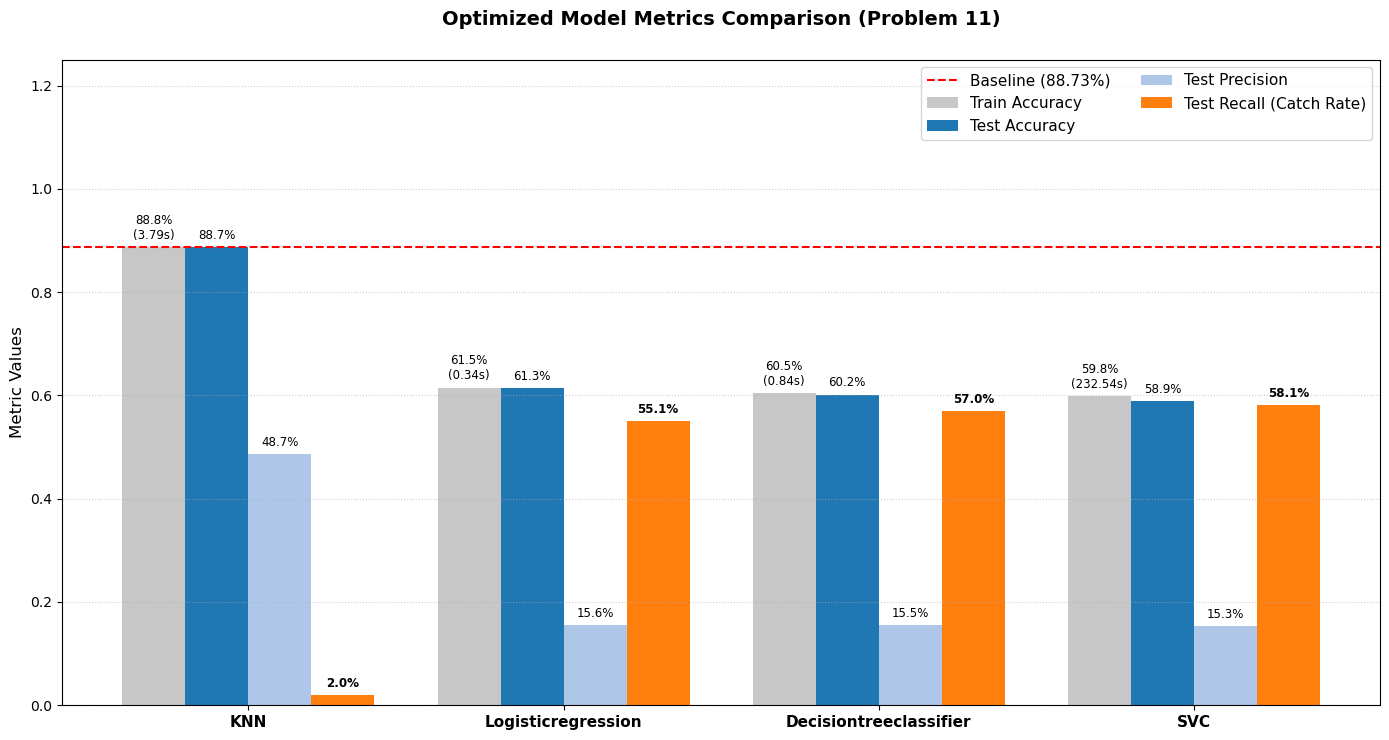

In [41]:
# Improved model performance DataFrame columns
model_names = df_improved_performance['Model'].tolist()
train_acc   = df_improved_performance['Train Accuracy'].tolist()
test_acc    = df_improved_performance['Test Accuracy'].tolist()
precision   = df_improved_performance['Test Precision'].tolist()
recall      = df_improved_performance['Test Recall'].tolist()
fit_times   = df_improved_performance['Computation Time'].tolist()

# Baseline from Problem 7
baseline_accuracy = 0.8873  

x = np.arange(len(model_names))
width = 0.20 # Width of a single discrete bar

fig, ax = plt.subplots(figsize=(14, 7.5))

# Generate the 4 discrete bars per model group
rects1 = ax.bar(x - 1.5*width, train_acc, width, label='Train Accuracy', color='#c7c7c7')
rects2 = ax.bar(x - 0.5*width, test_acc,  width, label='Test Accuracy',  color='#1f77b4')
rects3 = ax.bar(x + 0.5*width, precision, width, label='Test Precision', color='#aec7e8')
rects4 = ax.bar(x + 1.5*width, recall,    width, label='Test Recall (Catch Rate)', color='#ff7f0e')

# Draw baseline line from Problem 7
ax.axhline(y=baseline_accuracy, color='r', linestyle='--', linewidth=1.5, 
           label=f'Baseline ({baseline_accuracy*100:.2f}%)')

# Style Chart Elements
ax.set_ylabel('Metric Values', fontsize=12)
ax.set_title('Optimized Model Metrics Comparison (Problem 11)', fontsize=14, fontweight='bold', pad=25)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11, fontweight='semibold')
ax.set_ylim(0, 1.25)  
ax.legend(loc='upper right', fontsize=11, ncol=2) 
ax.grid(axis='y', linestyle=':', alpha=0.6)

# Add data labels above the bars
for i, rect in enumerate(rects1):
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width() / 2, height + 0.01,
            f'{height:.1%}\n({fit_times[i]:.2f}s)', 
            ha='center', va='bottom', fontsize=8.5, linespacing=1.2)

for rect in rects2:
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width() / 2, height + 0.01, 
            f'{height:.1%}', ha='center', va='bottom', fontsize=8.5)

for rect in rects3:
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width() / 2, height + 0.01, 
            f'{height:.1%}', ha='center', va='bottom', fontsize=8.5)

for rect in rects4:
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width() / 2, height + 0.01, 
            f'{height:.1%}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.show()

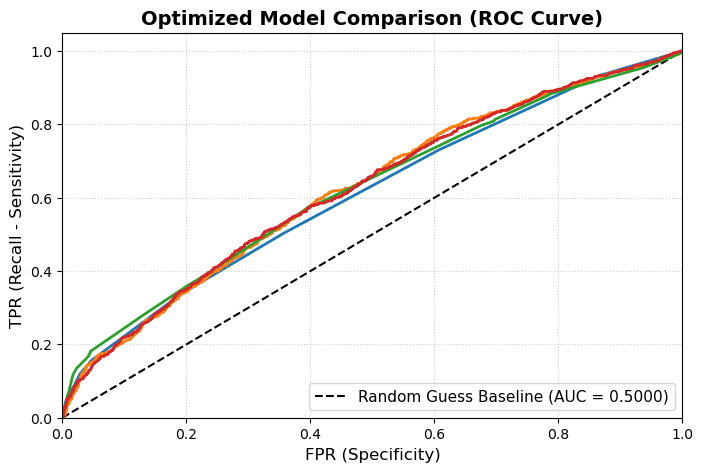

In [42]:
plt.figure(figsize=(8, 5))

# Plot the diagonal baseline (Random Guessing = 0.5)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess Baseline (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR (Specificity)', fontsize=12)
plt.ylabel('TPR (Recall - Sensitivity)', fontsize=12)
plt.title('Optimized Model Comparison (ROC Curve)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

# Plot each model ROC curve
for res in custom_results:
    key = res[0]
    model_name = res[0].upper() if len(res[0]) <= 3 else res[0].title()
    roc_auc = res[7]
    fpr = res[9]
    tpr = res[10]
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.4f})', linewidth=2)
    
plt.show()

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

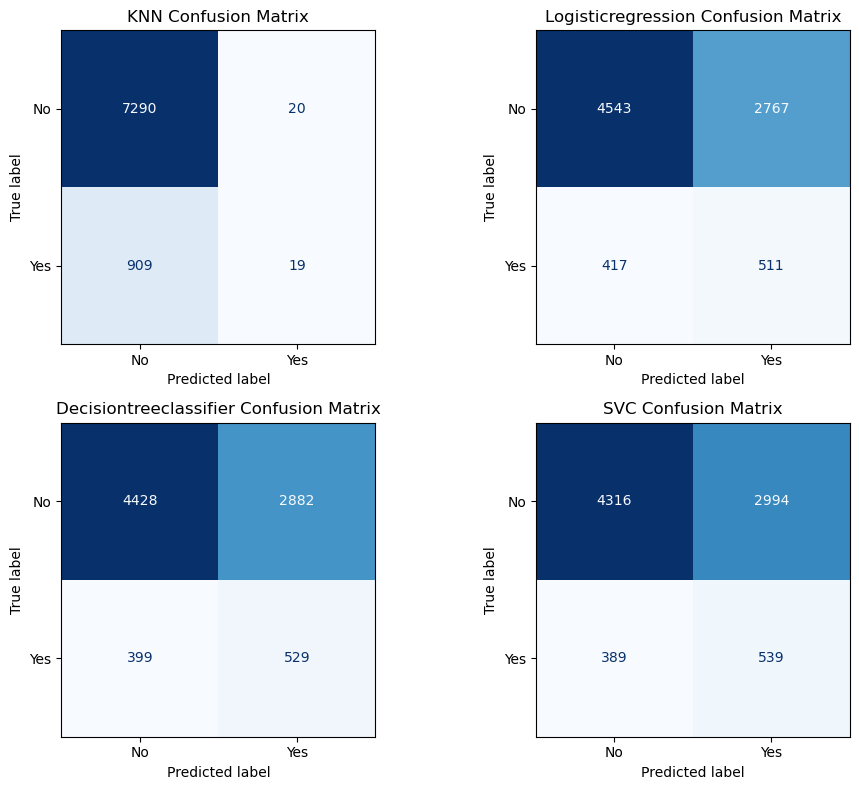

In [44]:
# Set up a 2x2 grid to show all models side-by-side
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for i, res in enumerate(custom_results):
    key = res[0]
    model_name = key.upper() if len(key) <= 3 else key.title()
    
    # Extract TN, FP, FN, TP
    tn, fp, fn, tp = res[8].ravel()
    
    # Plot the visual matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=res[8], display_labels=['No', 'Yes'])
    disp.plot(ax=axes[i], cmap='Blues', values_format='d', colorbar=False)
    axes[i].set_title(f'{model_name} Confusion Matrix')

plt.tight_layout()
plt.show()

### Optimization Takeaways

* **KNN fell into the majority-class trap:** Without a built-in way to handle the class imbalance, the hyperparameter search picked a high neighbor count (21) simply to maximize overall accuracy. By blindly guessing "no" most of the time, it missed actual predictive patterns, leaving it with the lowest test score (0.6089 ROC AUC) and catching almost zero subscribers.
* **Class balancing corrected model behavior:** Turning on `class_weight='balanced'` forced Logistic Regression, Decision Trees, and SVC to prioritize the heavily outnumbered subscriber group. While this dropped global accuracy to the 58%–61% range, it successfully broke the models out of their blind spot so they could flag actual buyers.
* **Decision Tree was the top operational choice:** If the goal is maximizing marketing reach (Recall), the Decision Tree performed exceptionally well by catching 529 true subscribers (beating Logistic Regression's 511). Capping the tree at `max_depth: 6` successfully controlled variance and kept overfitting to a minimum. Even though the absolute highest catch count was observed in SVC (539), its massive 700x training time slowdown heavily outweighs that slight edge.
* **Logistic Regression gave the cleanest baseline:** It delivered a matching top-tier score (0.6226 ROC AUC) with virtually no gap between training and testing performance, all while running near-instantly in just 0.33 seconds.
* **SVC isn't worth the wait:** The RBF kernel found a solid decision boundary (0.6225 ROC AUC) and caught 539 subscribers, but its 231.56-second training time creates a massive bottleneck. It is impossible to justify when simpler alternatives match its performance instantly.

### Executive Summary: Bank Marketing Model Comparison

#### The Core Challenge: The Accuracy Trap
The campaign dataset is heavily lopsided, with roughly 89% "no" answers and only 11% "yes" responses. In this scenario, standard accuracy is a highly misleading metric. A model could simply guess "no" for every single customer, score an impressive 88.7% accuracy, and completely fail the business. 

For a telemarketing team, the priority is finding the customers who will actually say "yes" (True Positives). Missing a willing subscriber means direct lost revenue. On the other hand, calling someone who says "no" only costs a few minutes of a representative's time. Because the penalty for missing a customer is so high, we must prioritize Recall (the total catch rate) over raw accuracy.

#### Framework Conclusions & Next Steps
The **Decision Tree** is the best model for immediate deployment because it maximizes customer acquisition without a massive time penalty. However, any model built purely on basic client demographics will eventually hit a performance ceiling. 

To significantly lift conversion rates, future modeling phases should expand beyond basic demographic profiles to fully incorporate the remaining behavioral and economic features already present in the dataset:

1. **Past Campaign Data:** Utilizing features like `pdays` (days since last contact) and `previous` (number of past interactions) will capture a customer's immediate interest or momentum.
2. **Economic Indicators:** Factoring in the existing social and economic attributes—such as interest rates and consumer price indices—will help the model adapt to real-world economic shifts, keeping marketing lists highly accurate over time.

##### Questions